In [1]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.shape

(41188, 21)

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [8]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [9]:
df["y"] = df["y"].map({"yes": 1, "no": 0})

In [10]:
df["y"].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

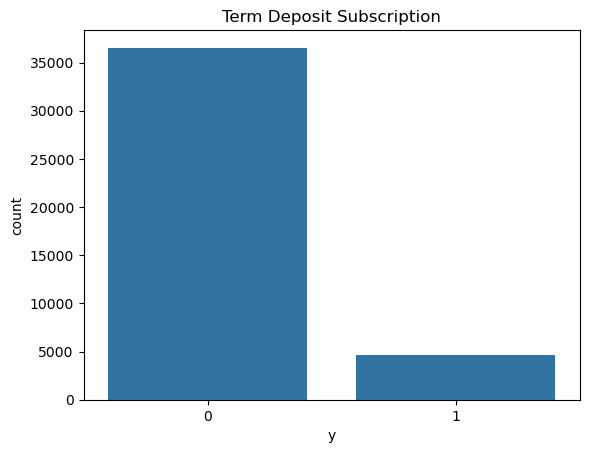

In [11]:
sns.countplot(x="y", data=df)
plt.title("Term Deposit Subscription")
plt.show()

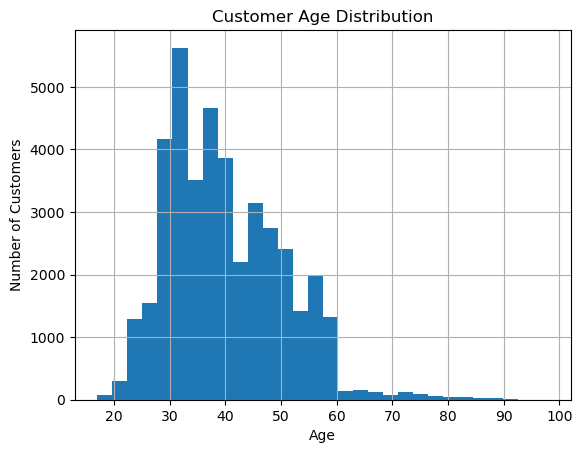

In [12]:
df["age"].hist(bins=30)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

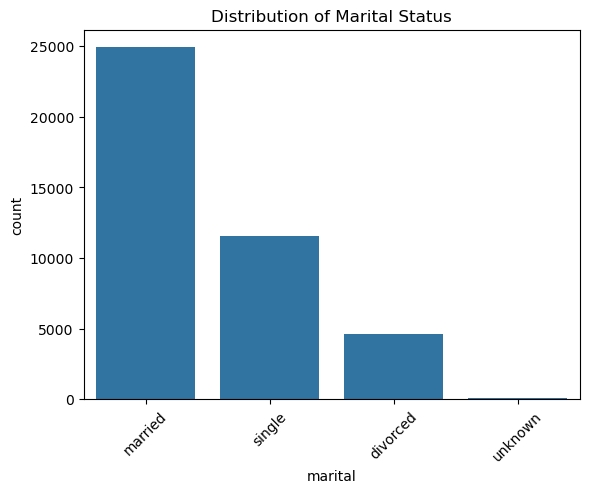

In [13]:
sns.countplot(x="marital", data=df)
plt.title("Distribution of Marital Status")
plt.xticks(rotation=45)
plt.show()

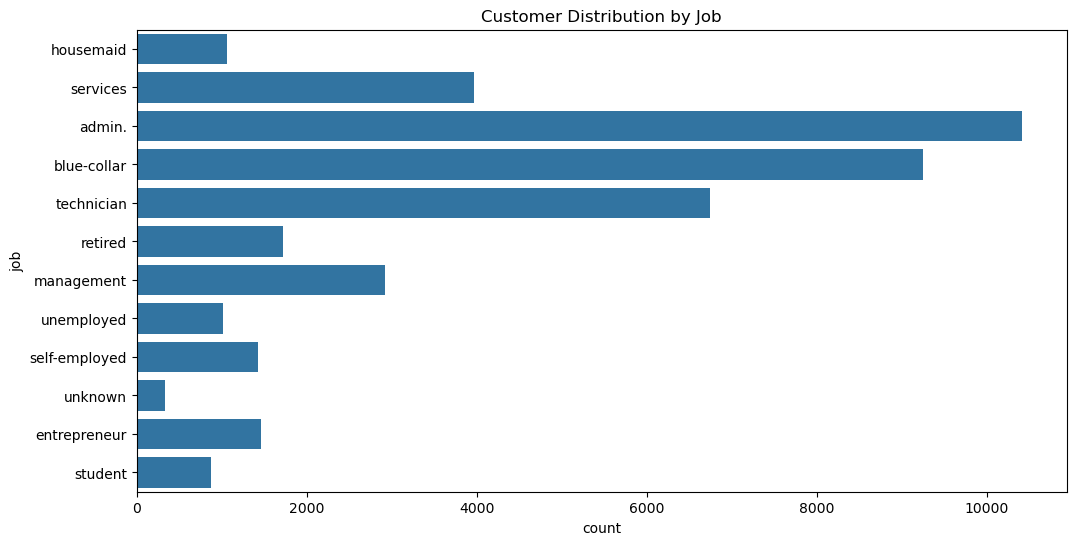

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(y="job", data=df)
plt.title("Customer Distribution by Job")
plt.show()

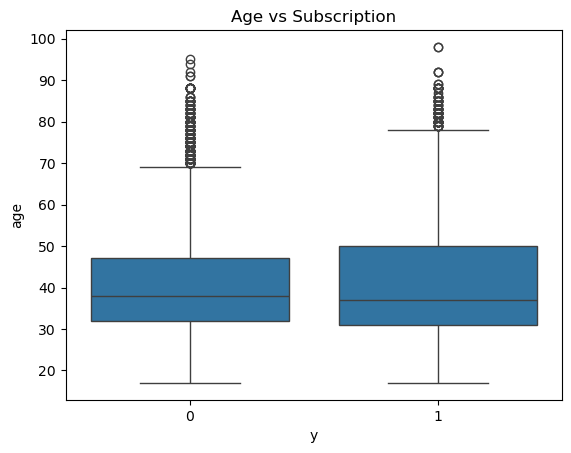

In [15]:
sns.boxplot(x="y", y="age", data=df)
plt.title("Age vs Subscription")
plt.show()

In [16]:
pd.crosstab(df["marital"], df["y"])

y,0,1
marital,,
divorced,4136,476
married,22396,2532
single,9948,1620
unknown,68,12


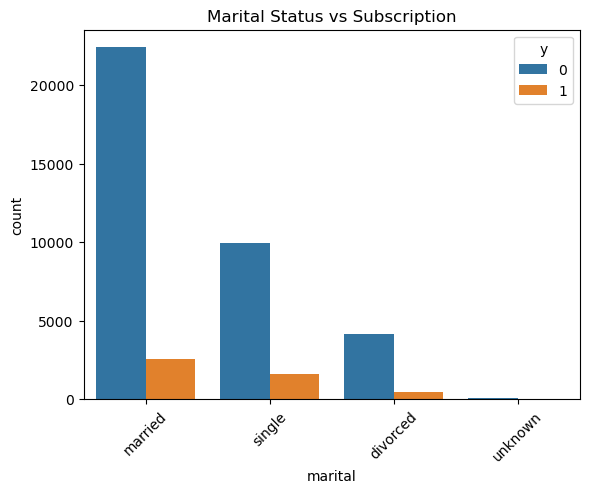

In [17]:
sns.countplot(x="marital", hue="y", data=df)
plt.title("Marital Status vs Subscription")
plt.xticks(rotation=45)
plt.show()

In [18]:
numeric_df = df.select_dtypes(include="number")
numeric_df.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0


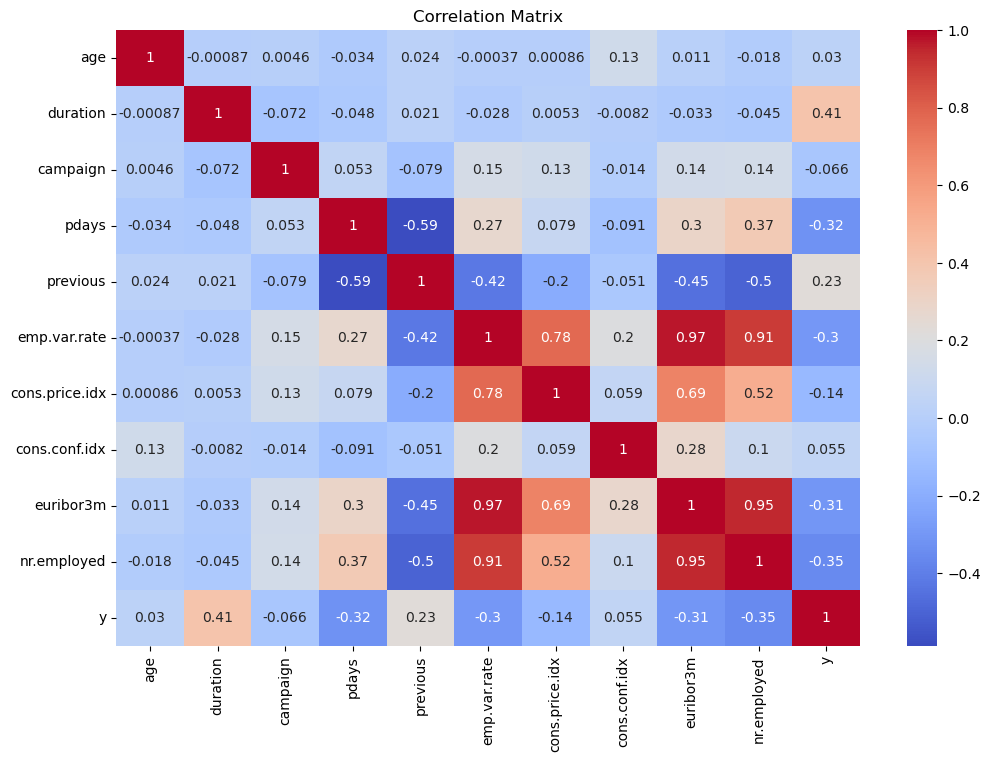

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [20]:
df.groupby("job")["y"].mean().sort_values(ascending=False)

job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: y, dtype: float64

In [21]:
numeric_df.corr()["y"].sort_values(ascending=False)

y                 1.000000
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64

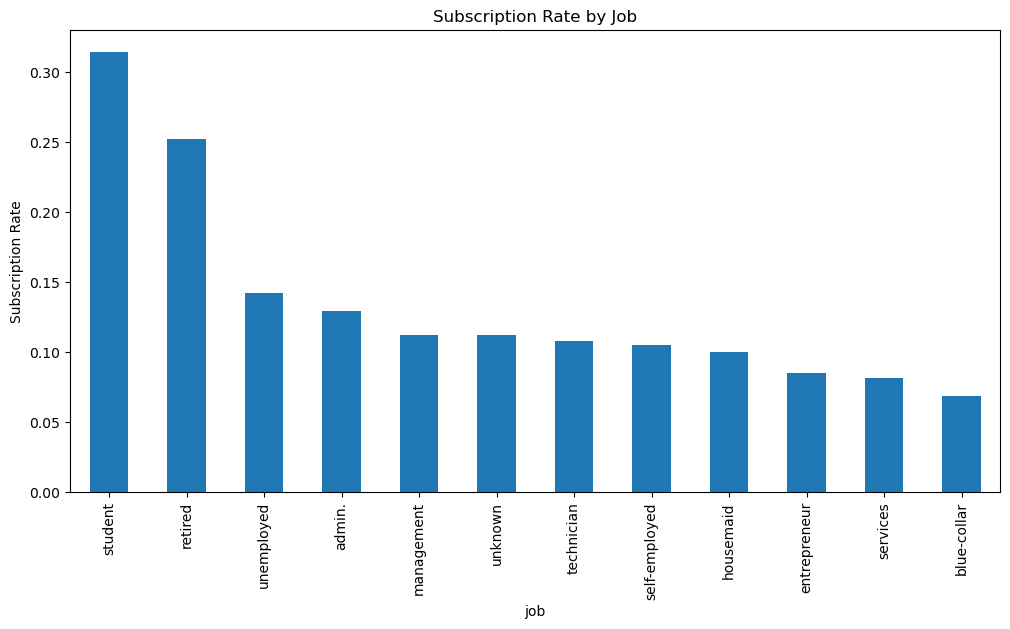

In [22]:
job_rate = df.groupby("job")["y"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
job_rate.plot(kind="bar")
plt.title("Subscription Rate by Job")
plt.ylabel("Subscription Rate")
plt.show()

# Key Findings

1. Most customers in the dataset are married.
2. Administrative jobs are the most common among customers.
3. Most customers belong to the age group of 30 to 50 years.
4. The number of customers who did not subscribe is much higher than those who subscribed.
5. Students, retired individuals, and unemployed customers showed higher subscription rates compared to other job groups.
6. Call duration had the strongest relationship with customer subscriptions.

# Business Recommendations

1. Focus marketing efforts on customer groups with higher subscription rates, such as students and retired customers.
2. Improve customer interaction during calls to increase the chances of subscription.
3. Create targeted marketing campaigns for different customer segments.
4. Use customer data to better understand customer behavior and improve campaign performance.

# Conclusion

In this project, I analyzed the Bank Marketing dataset using Python, Pandas, Matplotlib, and Seaborn. The analysis helped identify customer characteristics and factors that influence term deposit subscriptions. The findings can help banks improve their marketing strategies and target potential customers more effectively.